In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


In [25]:
df=pd.read_csv('economic_index.csv')

In [26]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [27]:
df.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

Text(0.5, 1.0, 'economic graph')

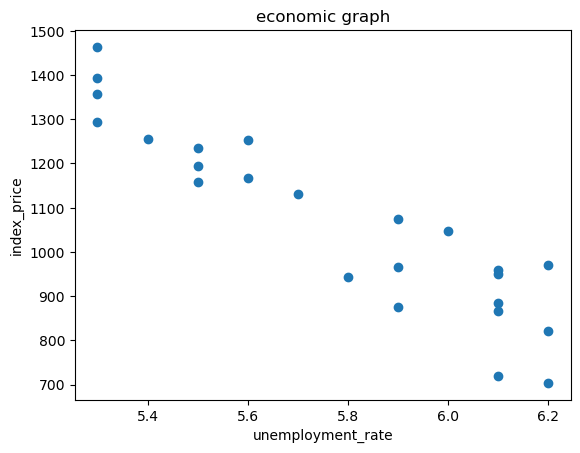

In [33]:
plt.scatter(df['unemployment_rate'],df['index_price'])
plt.xlabel("unemployment_rate")
plt.ylabel("index_price")
plt.title("economic graph")

Text(0.5, 1.0, 'economic graph')

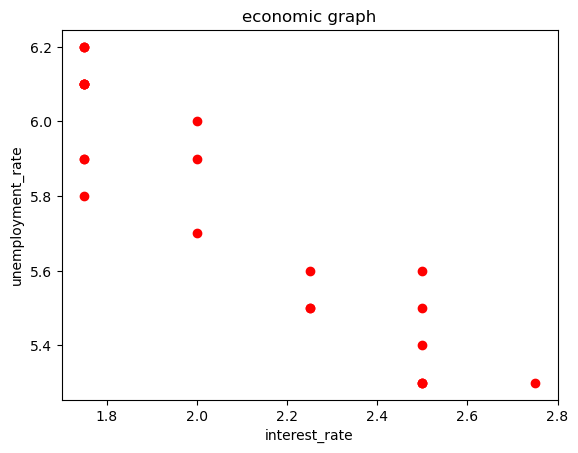

In [36]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='red')
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")
plt.title("economic graph")

In [29]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [30]:
import seaborn as sns

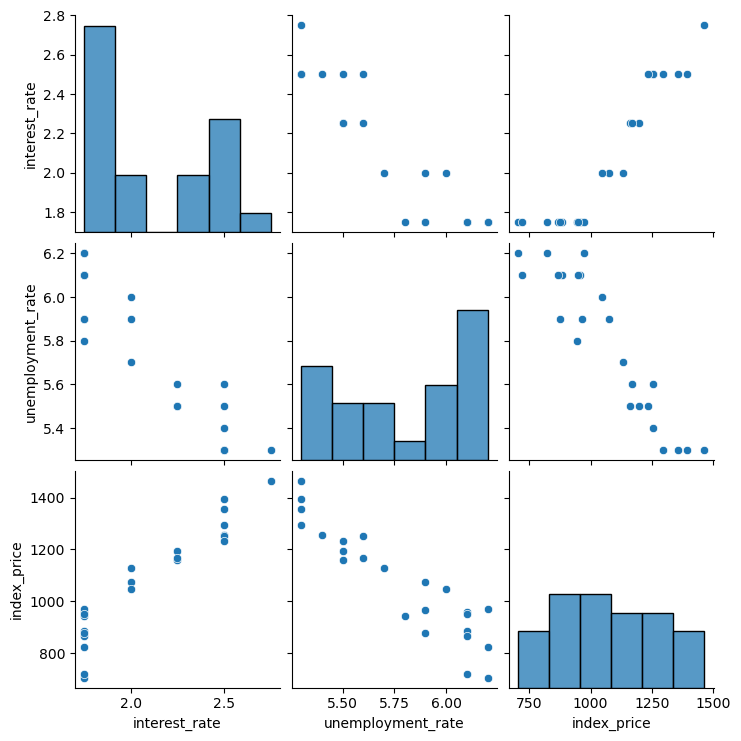

In [41]:
sns.pairplot(df)

In [32]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [42]:
#independent and dependent feature
X=df.iloc[ : , :-1]
y=df.iloc[:,-1]

In [43]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [44]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [50]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

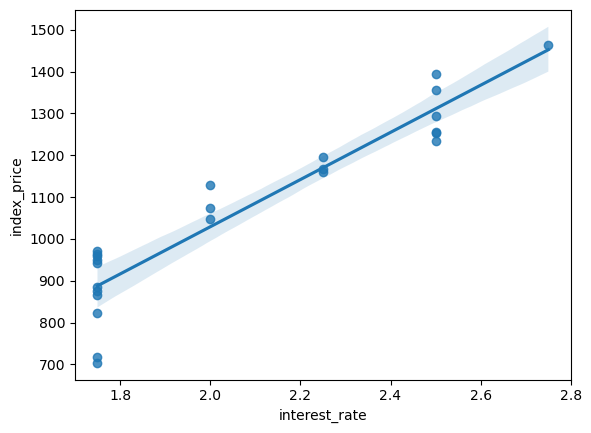

In [55]:
sns.regplot(x=df['interest_rate'],y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

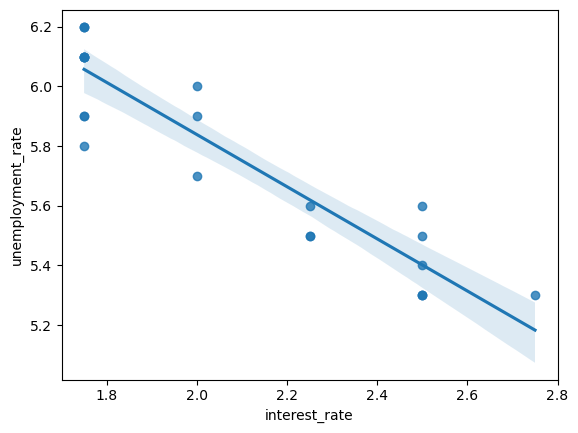

In [56]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'])

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
regression =LinearRegression(n_jobs=-1)

In [61]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [64]:
print("the slope is:",regression.coef_)
print("the intercept is",regression.intercept_)

the slope is: [  88.27275507 -116.25716066]
the intercept is 1053.4444444444443


In [67]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error",
                                 cv=3)

In [68]:
np.mean(validation_score)

np.float64(-5914.828180162388)

In [69]:
y_pred=regression.predict(X_test)
print(y_pred)

[1204.22770398  821.65051903 1406.51300368  857.70889608  994.90992298
 1168.16932693]


In [70]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [71]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712579
59.935781523235526
76.11677139574812


In [73]:
from sklearn.metrics import r2_score

In [74]:
score=r2_score(y_test,y_pred)
print(score)

0.8278978091457142


In [75]:
adjusted_r_squared=1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(adjusted_r_squared)


0.713163015242857


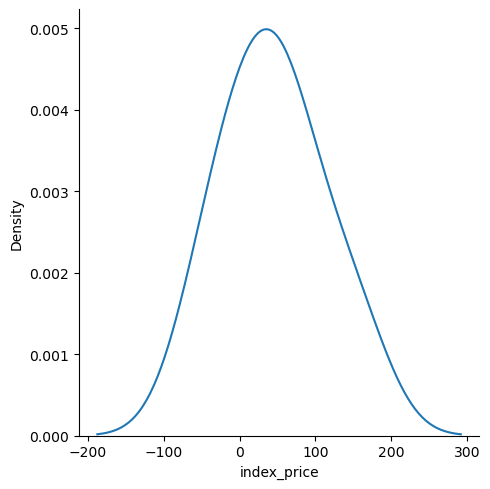

In [76]:
sns.displot(y_test-y_pred,kind='kde')

In [77]:
import statsmodels.api as sm

In [78]:
model=sm.OLS(y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)

[ 150.78325954 -231.79392541  353.06855924 -195.73554836  -58.53452146
  114.72488249]


In [82]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 23 Feb 2026   Prob (F-statistic):                       0.754
Time:                        07:46:04   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

<bound method RegressionResults.summary of <statsmodels.regression.linear_model.OLSResults object at 0x000002F53F754980>>
